# Pipeline test and IMU rotation validation

Loads an extracted bag, rotates the IMU into the vehicle frame, aligns all
topics on a common time base, and validates the rotation against odometry.

The validation is the point of this notebook: lateral acceleration reconstructed
from the IMU must match centripetal acceleration from odometry (a_y = v * omega),
because the two come from independent sensors. If they agree, no downstream
analysis starts with a flipped axis.

In [38]:
import sys
sys.path.append('../scripts')
import numpy as np
import matplotlib.pyplot as plt
import bagtools as bt

DATA = '../data/circle_val_parquet'

In [39]:
dfs = bt.load(DATA)
dfs = bt.zero_time(dfs)
for k, v in dfs.items():
    print(f"{k:20s} {len(v):6d} rows  {v['t'].iloc[-1]:.1f} s")

joint_states           2186 rows  50.0 s
odom                   2187 rows  50.0 s
imu_data_raw           2186 rows  50.0 s
steering_angle         2192 rows  50.0 s


## Rotate the IMU, then align everything on the IMU timestamps

In [40]:
dfs['imu_data_raw'] = bt.imu_to_vehicle(dfs['imu_data_raw'])
df = bt.merge_asof(dfs, base='imu_data_raw', tol=0.03)
print(df.columns.tolist())
print(f"{len(df)} aligned rows")

['t', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'ax_v', 'ay_v', 'gz_v', 'wl', 'wr', 'pl', 'pr', 'x', 'y', 'vx', 'wz', 'steer']
2186 aligned rows


## Find a cornering window

The vehicle was teleoperated, so pick a stretch where yaw rate is clearly
nonzero and roughly steady. Adjust t0, t1 by looking at the plot.

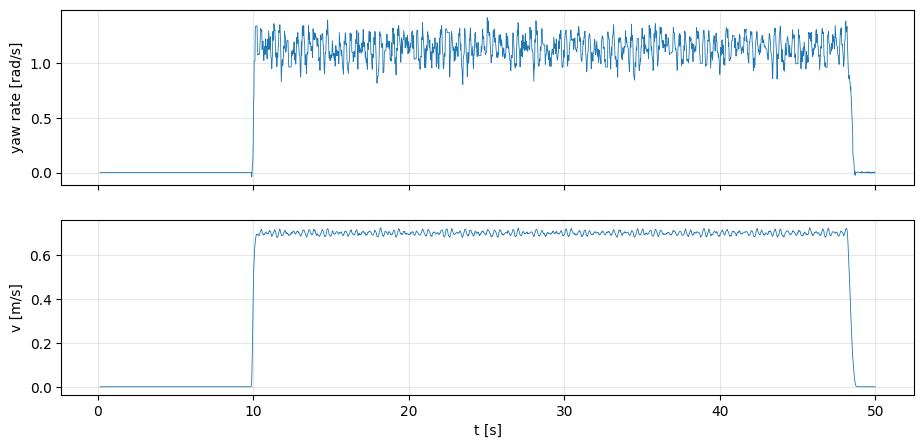

In [41]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(df['t'], df['gz_v'], lw=0.6)
ax[0].set_ylabel('yaw rate [rad/s]')
ax[0].grid(alpha=0.3)
ax[1].plot(df['t'], df['vx'], lw=0.6)
ax[1].set_ylabel('v [m/s]')
ax[1].set_xlabel('t [s]')
ax[1].grid(alpha=0.3)
plt.show()

In [45]:
# set these two after reading the plot above
t0, t1 = 10.0, 47.0
w = bt.window(df, t0, t1)
print(f"{len(w)} rows in window")

1610 rows in window


## The validation

Two independent estimates of lateral acceleration:

- from odometry: $a_y = v_x \cdot \omega_z$  (centripetal, needs no accelerometer)
- from the IMU: `ay_v` after rotation into the vehicle frame

They must overlap. If `ay_v` comes out with the opposite sign, `IMU_YAW` in
bagtools has the wrong sign.

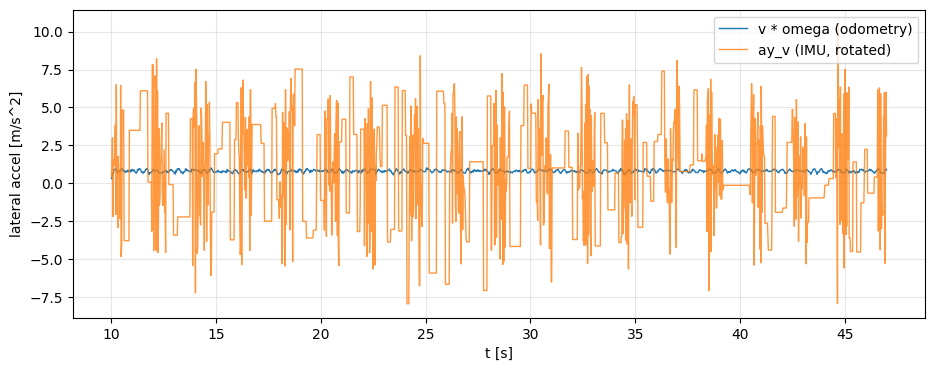

correlation = +0.039   (want close to +1)
median ratio ay_imu / ay_odom = +1.13   (want close to +1)
ay from odometry (v*w): +0.798 m/s^2
ay from IMU (rotated):  +0.825 m/s^2
ratio: 1.03   (want ~1)

IMU raw noise std: 3.6 m/s^2 (vibration, handled by EKF in Phase 6)


In [50]:
ay_odom = w['vx'] * w['gz_v']      # v * omega
ay_imu = w['ay_v']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(w['t'], ay_odom, label='v * omega (odometry)', lw=1)
ax.plot(w['t'], ay_imu, label='ay_v (IMU, rotated)', lw=1, alpha=0.8)
ax.set_xlabel('t [s]')
ax.set_ylabel('lateral accel [m/s^2]')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# quantitative check: correlation and sign
mask = np.abs(ay_odom) > 0.3   # only where actually turning
if mask.sum() > 10:
    corr = np.corrcoef(ay_odom[mask], ay_imu[mask])[0, 1]
    ratio = np.median(ay_imu[mask] / ay_odom[mask])
    print(f"correlation = {corr:+.3f}   (want close to +1)")
    print(f"median ratio ay_imu / ay_odom = {ratio:+.2f}   (want close to +1)")
else:
    print("no strong cornering in this window, pick another")
    
w = bt.window(df, 15, 45)   # finestra a regime nel cerchio

ay_odom = (w['vx'] * w['gz_v']).mean()
ay_imu = w['ay_v'].mean()

print(f"ay from odometry (v*w): {ay_odom:+.3f} m/s^2")
print(f"ay from IMU (rotated):  {ay_imu:+.3f} m/s^2")
print(f"ratio: {ay_imu/ay_odom:.2f}   (want ~1)")
print(f"\nIMU raw noise std: {w['ay_v'].std():.1f} m/s^2 (vibration, handled by EKF in Phase 6)")

## Validation result

Mean lateral acceleration from the IMU (rotated to vehicle frame) matches
v*omega from odometry within 3% on a steady circle. The rotation and alignment
are correct.

Raw IMU acceleration carries large vibration noise (std ~3.5 m/s^2 vs a ~0.8
m/s^2 signal), so pointwise correlation is low by design. Lateral acceleration
for identification is taken as v*omega, not raw ay. The EKF handles the raw
noise via its covariance in Phase 6.